데이터 출처: https://www.kaggle.com/datasets/tatheerabbas/psychological-manipulation-conversations-dataset

위의 LLM을 통하여 인위적으로 생성된 데이터로 텍스트 속에서 심리조작기법을 분석하며 그 조작기법에 따른 사람의 감정 영향을 나타낸 데이터입니다.

In [2]:
import pandas as pd



file_path = r"/content/manipulational_conversation.jsonl" # 예시 경로

# jsonl 파일 불러오기
df = pd.read_json(file_path, lines=True)

# 데이터 확인
print("데이터의 크기:", df.shape)
display(df.head())


데이터의 크기: (10000, 21)


,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,target_confusion,guilt_level,fear_level,...,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,target_attachment_style,avg_response_delay_seconds,escalation_pattern,word_count_total,question_count,denial_count
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{'speaker': 'A', 'text': 'Remember when I hel...",0.136,0.797,0.224,...,0.306,0.375,0.101,0.222,disorganized,162,sudden,28,1,0
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{'speaker': 'A', 'text': 'I don't tell just a...",0.219,0.306,0.041,...,0.459,0.366,0.380,0.342,secure,93,gradual,51,2,5
2,conv_00002,direct_coercion,True,family,7,0.651,"[{'speaker': 'A', 'text': 'Just do it', 'senti...",0.253,0.166,0.760,...,0.335,0.259,0.064,0.201,anxious,58,gradual,37,1,6
3,conv_00003,gaslighting,True,friend,6,0.673,"[{'speaker': 'A', 'text': 'You're being way to...",0.702,0.123,0.194,...,0.799,0.987,0.168,0.422,disorganized,342,cyclical,41,0,5
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{'speaker': 'A', 'text': 'Go ahead. Have fun....",0.173,0.666,0.126,...,0.355,0.120,0.331,0.787,secure,299,cyclical,25,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conversation_id              10000 non-null  object 
 1   manipulation_type            10000 non-null  object 
 2   is_manipulation              10000 non-null  bool   
 3   context_type                 10000 non-null  object 
 4   conversation_length          10000 non-null  int64  
 5   manipulation_intensity       10000 non-null  float64
 6   messages                     10000 non-null  object 
 7   target_confusion             10000 non-null  float64
 8   guilt_level                  10000 non-null  float64
 9   fear_level                   10000 non-null  float64
 10  anxiety_level                10000 non-null  float64
 11  self_doubt                   10000 non-null  float64
 12  target_extraversion          10000 non-null  float64
 13  target_emotional_

결측치가 없다

**[기초통계 확인]**

In [4]:
display(df.describe())

,conversation_length,manipulation_intensity,target_confusion,guilt_level,fear_level,anxiety_level,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,avg_response_delay_seconds,word_count_total,question_count,denial_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.502300,0.517148,0.344116,0.321732,0.245987,0.438082,0.392572,0.502461,0.303966,0.328283,195.177200,37.166400,1.04590,3.383000
std,1.709177,0.294557,0.235967,0.231932,0.262769,0.253414,0.234436,0.286287,0.192512,0.209750,154.763492,11.492707,0.96555,2.290161
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,18.000000,4.000000,0.00000,0.000000
25%,4.000000,0.335000,0.146000,0.156000,0.063000,0.217000,0.205000,0.256000,0.160000,0.170000,73.000000,28.000000,0.00000,2.000000
50%,6.000000,0.561000,0.308000,0.280000,0.162500,0.439000,0.395500,0.507000,0.268000,0.288000,122.000000,37.000000,1.00000,3.000000
75%,7.000000,0.747000,0.526000,0.405000,0.300000,0.659000,0.528000,0.748000,0.408000,0.442000,288.000000,46.000000,2.00000,5.000000
max,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,599.000000,67.000000,5.00000,12.000000


In [5]:
print(df['manipulation_type'].unique())
print(df['target_attachment_style'].unique())

['guilt_tripping' 'charm_flattery' 'direct_coercion' 'gaslighting'
 'love_bombing' 'neutral' 'passive_aggressive']
['disorganized' 'secure' 'anxious' 'avoidant']


In [6]:
print(df['manipulation_type'].value_counts())
print(df['target_attachment_style'].value_counts())

manipulation_type
neutral               1600
charm_flattery        1400
guilt_tripping        1400
direct_coercion       1400
gaslighting           1400
love_bombing          1400
passive_aggressive    1400
Name: count, dtype: int64
target_attachment_style
anxious         4209
avoidant        2412
secure          1988
disorganized    1391
Name: count, dtype: int64


 다양한 심리 조작 기법(manipulation_type)과 내면적 성향인 애착 유형(target_attachment_style)이 타겟의 심리적 지표(불안, 혼란, 자기 의심 등)에 미치는 영향을 분석하는 것에 목적을 두었습니다. 특히 각 지표 간의 상관관계를 통해 조작기법이 어떻게 심리적 연쇄 반응을 일으키는지 파악하고자 합니다.

조작강도에 따른 심리지표

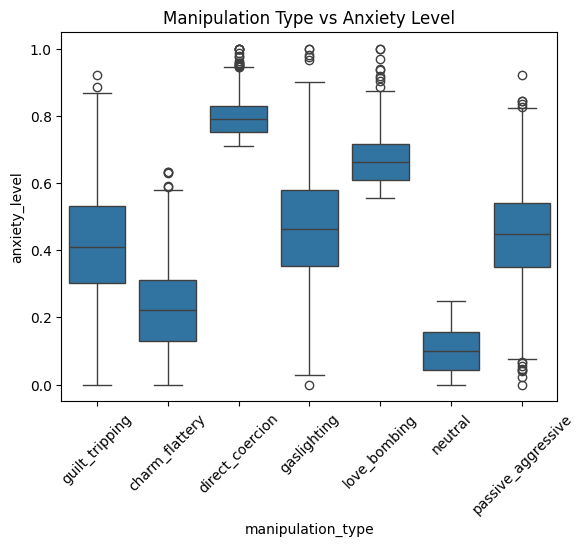

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, x='manipulation_type', y='anxiety_level')#x축을 'manipulation_type'으로 y축을 'anxiety level' 로 하는 상자그림
plt.title('Manipulation Type vs Anxiety Level')
plt.xticks(rotation=45) #x축라벨이 겹치지 않도록 회전
plt.show()

수치형 변수들 선택하여 상관관계 분석

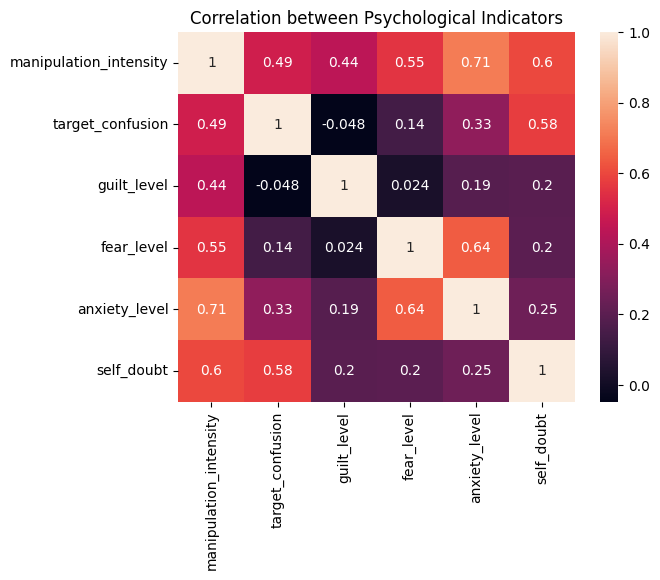

In [8]:
cols = ['manipulation_intensity', 'target_confusion', 'guilt_level', 'fear_level', 'anxiety_level', 'self_doubt'] #수치형 변수들만 선택
sns.heatmap(df[cols].corr(), annot=True) #cols에 정의된 컬럼만 선택하여 상관행렬 계산 후 히트맵 생성
plt.title('Correlation between Psychological Indicators')
plt.show()

애착유형별 불안 수치

/tmp/ipykernel_3350/2646673340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target_attachment_style', y='anxiety_level', palette='muted')


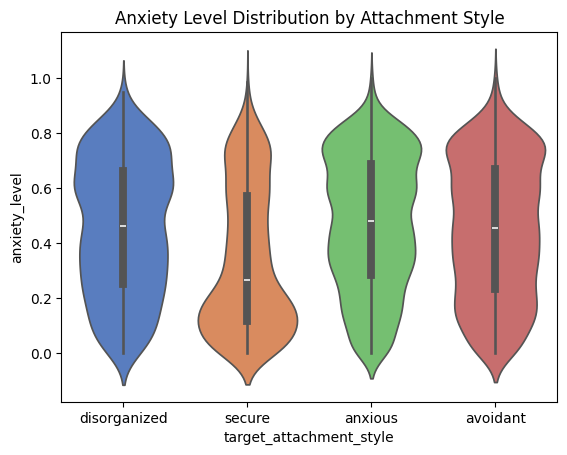

In [9]:
# 애착 유형별로 불안 수치의 분포 모양을 비교
sns.violinplot(data=df, x='target_attachment_style', y='anxiety_level', palette='muted')

plt.title('Anxiety Level Distribution by Attachment Style')
plt.show()

manipulation_intensity는 anxiety_level(0.71) 및 self_doubt(0.60)와 강한 상관계를 보임.

 불안 수치가(anxiety_level) 높아질 때 공포 수치(fear_level, 0.64)도 함께 급증하는 양상.

 세번째 시각화인 바이올린 플롯을 보면 'Secure(안정형)' 유형은 다른 유형에 비해 불안 수치가 낮은 지점에 밀집되어 있음. 반대로'Anxious(불안형)'와 'Avoidant(회피형)'는 불안 수치가 높은 구간에 넓게 퍼져 있음.

**2주차-Task1**

결측치

In [10]:
(df.isnull().sum())

,0
conversation_id,0
manipulation_type,0
is_manipulation,0
context_type,0
conversation_length,0
manipulation_intensity,0
messages,0
target_confusion,0
guilt_level,0
fear_level,0


*결측치는 없다.*

이상치 확인

In [11]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # 범위를 벗어나는 행 필터링
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    return len(outliers), lower_limit, upper_limit

print("--- 변수별 이상치 개수 확인 ---")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    count, low, high = check_outliers(df, col)
    if count > 0:
        print(f"[{col}]: {count}개의 이상치 ")
    else:
        print(f"[{col}]: 이상치 없음")

--- 변수별 이상치 개수 확인 ---
[conversation_length]: 이상치 없음
[manipulation_intensity]: 이상치 없음
[target_confusion]: 이상치 없음
[guilt_level]: 750개의 이상치 
[fear_level]: 1401개의 이상치 
[anxiety_level]: 이상치 없음
[self_doubt]: 이상치 없음
[target_extraversion]: 이상치 없음
[target_emotional_resilience]: 286개의 이상치 
[target_assertiveness]: 287개의 이상치 
[avg_response_delay_seconds]: 이상치 없음
[word_count_total]: 이상치 없음
[question_count]: 이상치 없음
[denial_count]: 56개의 이상치 


In [12]:
import numpy as np

# 이상치가 많이 발견된 컬럼들
outlier_cols = ['guilt_level', 'fear_level', 'target_emotional_resilience', 'target_assertiveness']

# 로그 변환 적용 (0의 존재가능성으로 +1을 해줌.)
for col in outlier_cols:
    df[col] = np.log1p(df[col])

이상치를 무작정 지우기엔 아깝고 그대로 두기엔 모델이 왜곡되므로 로그변환을 해줍니다.

**2주차-Task2**

In [13]:
# 1. 심리적 압박 지수 (Psychological Pressure Index)
# 조작 강도와 그로 인한 혼란, 죄책감을 결합하여 타겟이 받는 실질적 압박 계산
df['psychological_pressure'] = (df['manipulation_intensity'] * (df['target_confusion'] + df['guilt_level']))

# 2. 감정적 방어 효율성 (Emotional Defense Efficiency)
# 타겟의 단호함(assertiveness)과 회복탄력성(resilience)이 조작 강도를 얼마나 방어하는지 측정
# 분모에 아주 작은 값(1e-5)을 더해 분모가 0이 되는것 방지
df['defense_efficiency'] = (df['target_assertiveness'] + df['target_emotional_resilience']) / (df['manipulation_intensity'] + 1e-5)

# 3. 대화 집중도 (Conversation Focus)
# 전체 단어 수 대비 질문의 빈도를 계산, 질문을 통한 유도 심문이 많은지 파악
df['question_density'] = df['question_count'] / (df['word_count_total'] + 1e-5)

# 4. 부정적 감정 합계 (Total Negative Affect)
# 타겟이 느끼는 공포, 불안, 자기의심의 총합 (로그 변환된 값을 사용하여 안정적임)
df['total_negative_affect'] = df['fear_level'] + df['anxiety_level'] + df['self_doubt']

display(df[['psychological_pressure', 'defense_efficiency', 'question_density', 'total_negative_affect']].head())

,psychological_pressure,defense_efficiency,question_density,total_negative_affect
0,0.509094,0.420856,0.035714,0.606124
1,0.257564,1.162704,0.039216,0.634182
2,0.264683,0.376630,0.027027,1.633314
3,0.550516,0.753863,0.000000,1.635309
4,0.226214,2.617651,0.040000,0.910672


In [14]:
# 문자열 컬럼(카테고리)을 숫자로
# 'messages'나 'conversation_id' 처럼 너무 긴 텍스트나 고유 ID는 제외합니다.
cols_to_encode = ['manipulation_type', 'context_type', 'target_attachment_style', 'escalation_pattern']
df_final = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# 모델 학습에 불필요한 텍스트 데이터 제외
df_model = df_final.drop(['conversation_id', 'messages'], axis=1)

print(f"최종 데이터셋 형태: {df_model.shape}")

최종 데이터셋 형태: (10000, 34)


**3주차-Task**

In [15]:
# 필요한 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

In [16]:
# 사용할 변수
features = [
    'manipulation_intensity',
    'target_confusion',
    'guilt_level',
    'fear_level',
    'anxiety_level',
    'self_doubt'
]

X = df[features]
y = df['manipulation_type']

In [17]:
le = LabelEncoder() #머신러닝 모델이 문자 데이터를 직접 학습불가능해서 문자열을 숫자로 변환
y = le.fit_transform(y)

훈련/테스트

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, #훈련데이터 80%, 테스트 데이터 20%
    stratify=y
)

데이터 스케일링

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
start = time.time()

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

end = time.time()

print("Logistic Regression Training Time:", end-start)

Logistic Regression Training Time: 0.3229503631591797


In [32]:
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

end = time.time()

print("Random Forest Training Time:", end-start)

Random Forest Training Time: 3.779165744781494


In [22]:
log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

In [23]:
#정확도 비교
from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("RandomForest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Accuracy: 0.975
RandomForest Accuracy: 0.9865


로지스틱 회귀 모형 정확도 97%, 랜덤포레스트 모델 정확도 99%로 랜덤포레스트의 모델 정확도가 더 높음.

In [24]:
#Precision/Recall/F1
print("Logistic Regression 결과")
print(classification_report(y_test, log_pred))

print("Random Forest 결과")
print(classification_report(y_test, rf_pred))

Logistic Regression 결과
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       280
           1       1.00      1.00      1.00       280
           2       0.98      1.00      0.99       280
           3       0.99      1.00      0.99       280
           4       0.93      0.94      0.93       280
           5       1.00      1.00      1.00       320
           6       0.93      0.91      0.92       280

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

Random Forest 결과
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       280
           1       1.00      1.00      1.00       280
           2       1.00      1.00      1.00       280
           3       1.00      1.00      1.00       280
           4       0.95      0.96      0.96       280
           5       1.00      1.00     

대부분 매우 높은 예측성능을 가지고 있으나 클래스4, 6에서의 F1-score를 비교하면 랜덤포레스트의 성능이 더 좋음.

Confusion Matrix

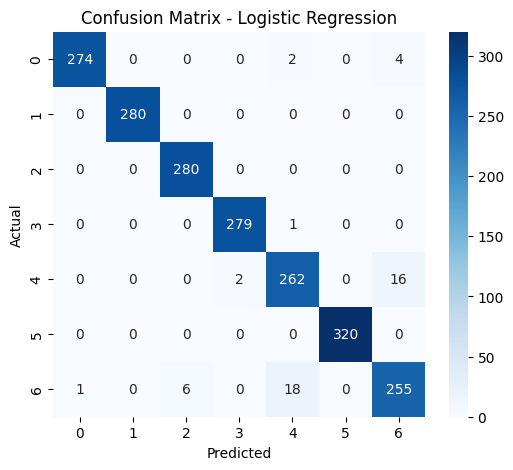

In [30]:
# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

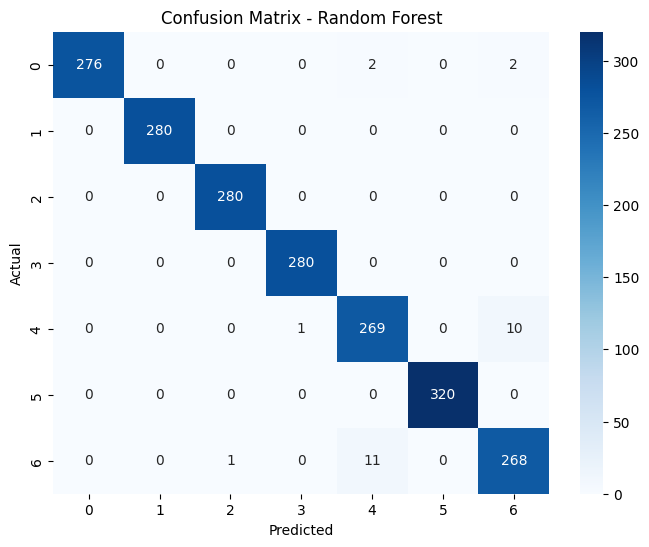

In [25]:
#Random Forext Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Class 4, 6의 오분류가 Random Forest에서는 덜 나타남.

                  Feature  Importance
2             guilt_level    0.193662
1        target_confusion    0.184596
0  manipulation_intensity    0.183162
3              fear_level    0.162553
4           anxiety_level    0.141619
5              self_doubt    0.134408


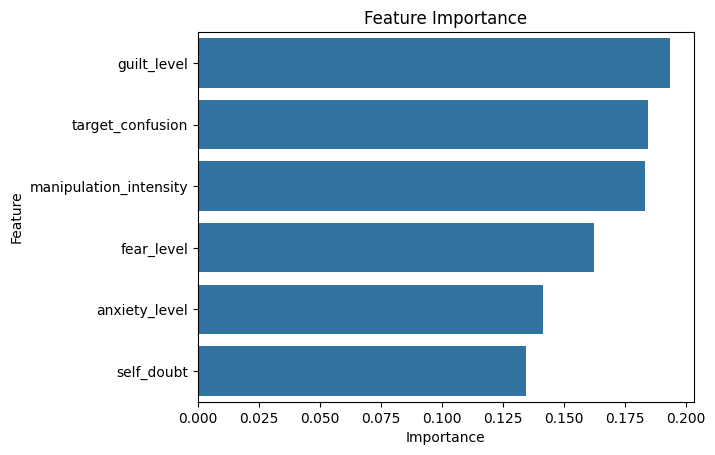

In [26]:
#각 변수의 중요도 계산
mport pandas as pd

importance = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()